In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')

os.makedirs('exported_charts', exist_ok=True)

rounds_stats_df = pd.read_csv('afl_players_round_by_round_stats_raw.csv', parse_dates=['match_date'])
home_away_match_df = pd.read_csv("team_matches_home_away_raw.csv", parse_dates=['match_date'])

print(rounds_stats_df.info())
print(home_away_match_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 274089 entries, 0 to 274088
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id                         274089 non-null  int64         
 1   team                       274089 non-null  str           
 2   year                       274089 non-null  int64         
 3   career_game_count          274089 non-null  int64         
 4   opponent                   274089 non-null  str           
 5   round                      274089 non-null  str           
 6   result                     274089 non-null  str           
 7   jersey_num                 274089 non-null  int64         
 8   kicks                      272789 non-null  float64       
 9   marks                      266038 non-null  float64       
 10  handballs                  269656 non-null  float64       
 11  disposals                  265636 non-null  float64       
 12 

### Data Cleaning

In [197]:
# Clean rounds_stats_df

numeric_cols_to_fill = rounds_stats_df.select_dtypes(include=['float64', 'int64']).columns
rounds_stats_df[numeric_cols_to_fill] = rounds_stats_df[numeric_cols_to_fill].fillna(0)

# string columns
string_cols_rounds = rounds_stats_df.select_dtypes(include=['object']).columns
for col in string_cols_rounds:
    rounds_stats_df[col] = rounds_stats_df[col].astype(str).str.strip()

print("rounds_stats_df after cleaning:")
print(rounds_stats_df.info())


C:\Users\MEE\AppData\Local\Temp\ipykernel_5908\3864717090.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols_rounds = rounds_stats_df.select_dtypes(include=['object']).columns


rounds_stats_df after cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 274089 entries, 0 to 274088
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id                         274089 non-null  int64         
 1   team                       274089 non-null  str           
 2   year                       274089 non-null  int64         
 3   career_game_count          274089 non-null  int64         
 4   opponent                   274089 non-null  str           
 5   round                      274089 non-null  str           
 6   result                     274089 non-null  str           
 7   jersey_num                 274089 non-null  int64         
 8   kicks                      274089 non-null  float64       
 9   marks                      274089 non-null  float64       
 10  handballs                  274089 non-null  float64       
 11  disposals                  2740

In [198]:
# Clean home_away_match_df

print("Missing crowd values:", home_away_match_df['crowd'].isna().sum())
print(len(home_away_match_df))

string_cols_home_away = home_away_match_df.select_dtypes(include=['object']).columns
for col in string_cols_home_away:
    home_away_match_df[col] = home_away_match_df[col].astype(str).str.strip()

home_away_match_df = home_away_match_df.rename(columns={"team_name": "team"})

home_away_match_df['team'] = home_away_match_df['team'].str.title()
home_away_match_df['opponent'] = home_away_match_df['opponent'].str.title()

team_name_map = {
    "W. Bulldogs": "Western Bulldogs",
}
home_away_match_df['team'] = home_away_match_df['team'].replace(team_name_map)
home_away_match_df['opponent'] = home_away_match_df['opponent'].replace(team_name_map)


print("Home away Data set after cleaning:")
print(home_away_match_df.info())


Missing crowd values: 398
15808
Home away Data set after cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 15808 entries, 0 to 15807
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       15808 non-null  int64         
 1   team                     15808 non-null  str           
 2   round                    15808 non-null  str           
 3   match_date               15808 non-null  datetime64[us]
 4   year                     15808 non-null  int64         
 5   home_away                15808 non-null  str           
 6   opponent                 15808 non-null  str           
 7   team_quarter_scores      15808 non-null  str           
 8   team_score               15808 non-null  int64         
 9   opponent_quarter_scores  15808 non-null  str           
 10  opponent_score           15808 non-null  int64         
 11  result                   15808 non-nu

C:\Users\MEE\AppData\Local\Temp\ipykernel_5908\2302003109.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols_home_away = home_away_match_df.select_dtypes(include=['object']).columns


### Relationship Discovery

In [199]:
common_cols = list(set(rounds_stats_df.columns) & set(home_away_match_df.columns))
print(common_cols)

['match_date', 'year', 'team', 'opponent', 'round', 'id', 'result', 'margin']


### Merging keys decision

Why a single key is insufficient:
-   Many matches occur within the same round, and a team plays multiple matches throughout a season and across different years. Therefore, using round or team alone cannot pinpoint a specific game.

Why a composite key is required:
- A composite key consisting of Year, Round, Team, Opponent, and Match Date is necessary. This combination verifies that we uniquely identify each specific instance of a match.

In [200]:
home_away_match_df = home_away_match_df.rename(columns={"team_name": "team"})
merge_keys = [
    "year",
    "round",
    "team",
    "opponent",
    "match_date"
]

#### Justifying

A single key is not sufficient such as round or team, because multiple matches happen every round and the same teams play multiple seasons. Therefore, combining mutilple keys is the way to go e.g; Season, Round, Team, Opponent uniquely identifies each team match and allows every player record to receive the correct match context.

### Context Enrichment

In [201]:
match_context = home_away_match_df[
    merge_keys + [
        "home_away",
        "venue",
        "crowd"
    ]
]

merged_df = pd.merge(
    rounds_stats_df,
    match_context,
    on=merge_keys,
    how="left"
)

merged_df.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin,home_away,venue,crowd
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,0.0,0.0,45552,1994-08-14,36,0.0,28,A,Melbourne Cricket Ground,52562.0
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,0.0,...,0.0,26.0,44356,2024-03-16,23,0.0,8,H,GMHBA Stadium,39352.0
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,0.0,0.0,45955,1999-06-04,67,0.0,48,A,AAMI Stadium,39389.0
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,0.0,0.0,45656,1994-08-13,81,0.0,45,A,Waverley Park,14653.0
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,0.0,0.0,45929,1997-05-31,32,0.0,-25,H,Melbourne Cricket Ground,28879.0


## Data Merge Validation

Verify that the number of player records remains unchanged.

In [202]:
# Before
before = len(rounds_stats_df)
# After
after = len(merged_df)

print(before)
print(after)

if before == after:
    print("==> Player count unchanged.")
else:
    print("==> Player count changed. After removing duplicate rows")

274089
274089
==> Player count unchanged.


Checking unmatched records

In [203]:
missing_context = merged_df[
    merged_df["venue"].isna()
]

print("Unmatched Records:", len(missing_context))

Unmatched Records: 0


### Missmatch Reason:

Before normalization, this check returned 55,000 unmatched records. problem was difference comparison of unique team/opponent values between the two datasets:

- 2,345 of 15,808 rows in home_away_match_df's opponent column were inconsistently lowercased (e.g. "essendon bombers" vs "Essendon Bombers").
- The Western Bulldogs were recorded as "W. Bulldogs" in the match dataset vs. "Western Bulldogs" in player stats.

After applying .str.title() normalization and a manual name mapping unmatched records dropped to 0.

Checking for duplicated records

In [204]:
duplicate_rows = merged_df[
    merged_df.duplicated()
]
print(duplicate_rows)

           id                 team  year  career_game_count  \
20963  556392       Hawthorn Hawks  1994                 17   
20964  614897         Geelong Cats  2024                  1   
20965  583553     Essendon Bombers  1999                 97   
20966  590676     Western Bulldogs  1994                 36   
20967  582473      Richmond Tigers  1997                113   
20968  540025      St Kilda Saints  2002                 24   
20969  507101    Fremantle Dockers  2002                 77   
20970  554875       Brisbane Lions  2002                 95   
20971  507061    Fremantle Dockers  1997                 37   
20972  501586  Port Adelaide Power  1997                 69   

                opponent round result  jersey_num  kicks  marks  ...  \
20963    Richmond Tigers    21      W          34    5.0    4.0  ...   
20964    St Kilda Saints     1      W           7    5.0    0.0  ...   
20965     Adelaide Crows    10      W           6   14.0    5.0  ...   
20966    St Kilda 

Removing Duplicates

In [205]:
print(f"Rows before removing pre-existing duplicates: {len(merged_df)}")
merged_df.drop_duplicates(keep='last', inplace=True)
print(f"Rows after removing pre-existing duplicates: {len(merged_df)}")

Rows before removing pre-existing duplicates: 274089
Rows after removing pre-existing duplicates: 274079


Dropped duplicated and merge data changed

### Contexual Analysis

Do Players have better performance at home or away?


In [206]:
players_perf_h_a = merged_df.groupby('home_away')['fantasy_points'].mean()
print(players_perf_h_a)

home_away
A    64.004408
H    66.485504
Name: fantasy_points, dtype: float64


Visualization

C:\Users\MEE\AppData\Local\Temp\ipykernel_5908\1744014902.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(players_perf_h_a, palette='viridis')


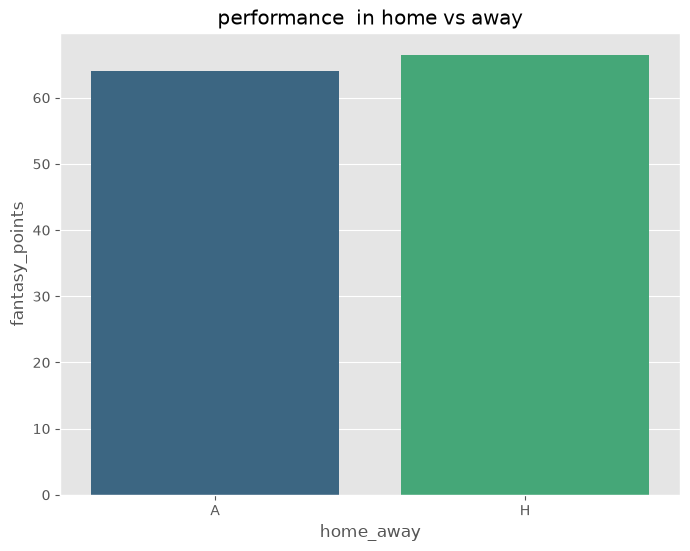

In [207]:
plt.figure(figsize=(8, 6))
plt.title("performance  in home vs away")
sns.barplot(players_perf_h_a, palette='viridis')
plt.savefig("exported_charts/Performance in home vs away.png")
plt.show()

C:\Users\MEE\AppData\Local\Temp\ipykernel_5908\1056463354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=players_perf_h_a.index, y=players_perf_h_a.values, palette='viridis')


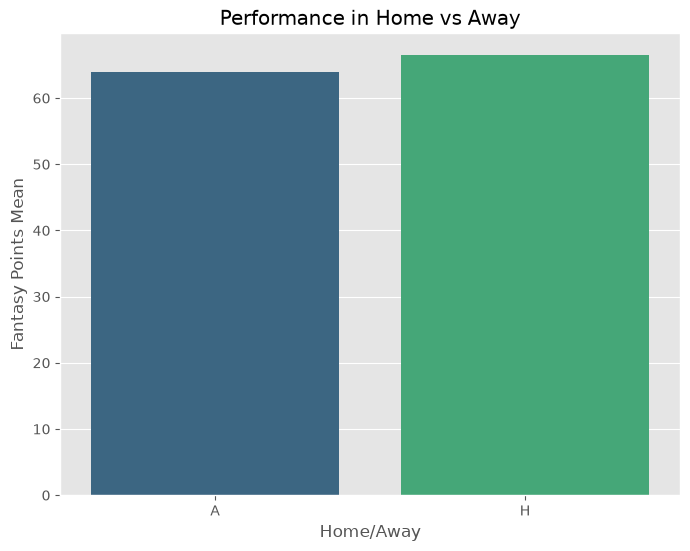

In [208]:
plt.figure(figsize=(8, 6))
plt.title("Performance in Home vs Away")
sns.barplot(x=players_perf_h_a.index, y=players_perf_h_a.values, palette='viridis')
plt.xlabel('Home/Away')
plt.ylabel('Fantasy Points Mean')
plt.savefig("exported_charts/Performance in home vs away.png")
plt.show()

We can find Crowd Influence by corelating the columns values.

In [209]:
correlation = merged_df[['crowd', 'fantasy_points']].corr()
print(correlation)

                   crowd  fantasy_points
crowd           1.000000        0.012891
fantasy_points  0.012891        1.000000


Visualization

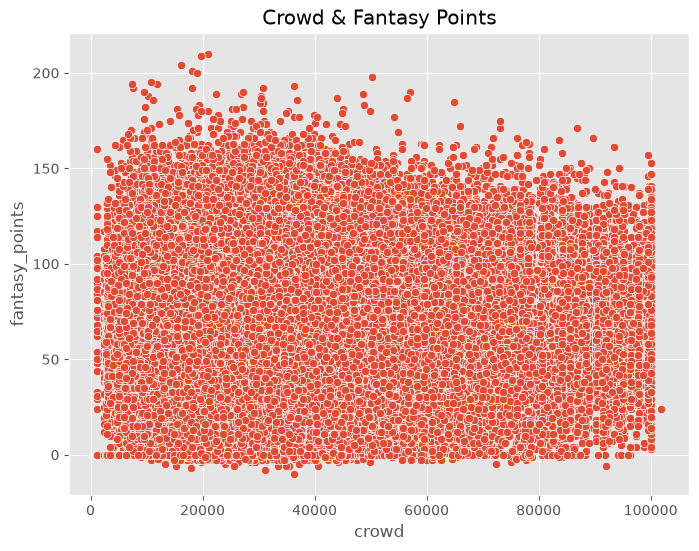

In [210]:
plt.figure(figsize=(8, 6))
plt.title("Crowd & Fantasy Points")

c_f_data = merged_df[['crowd', 'fantasy_points']].dropna()

sns.scatterplot(data=c_f_data, x='crowd', y='fantasy_points')
plt.savefig('exported_charts/ Crowd and fantasy points.png')
plt.show()


#### Q > Which venue produces highest player performance

In [211]:
venue_stats = merged_df.groupby('venue')['fantasy_points'].agg(['mean', 'count']).sort_values('mean', ascending=False)

MIN_RECORDS = 100
venue_stats_reliable = venue_stats[venue_stats['count'] >= MIN_RECORDS].head(10)

print(venue_stats_reliable)

                       mean  count
venue                             
Jiangwan Stadium  72.481752    137
Westpac Stadium   69.716418    134
TIO Traeger Park  69.615385    494
UTAS Stadium      68.051876   4318
ENGIE Stadium     67.826147   5033
Mars Stadium      67.756204    685
Marvel Stadium    67.570710  51902
Adelaide Oval     67.527898  13173
Norwood Oval      67.440433    277
TIO Stadium       67.102998   1301


Visualization

C:\Users\MEE\AppData\Local\Temp\ipykernel_5908\1045803367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=venue_stats_reliable['mean'].values, y=venue_stats_reliable.index, palette='viridis', legend=False)


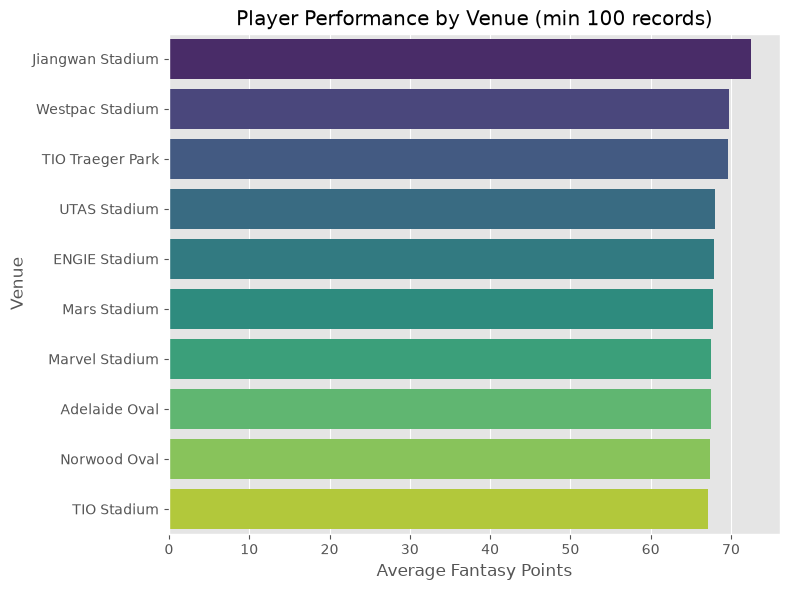

In [212]:
plt.figure(figsize=(8, 6))
plt.title(f"Player Performance by Venue (min {MIN_RECORDS} records)")
sns.barplot(x=venue_stats_reliable['mean'].values, y=venue_stats_reliable.index, palette='viridis', legend=False)
plt.xlabel('Average Fantasy Points')
plt.ylabel('Venue')
plt.tight_layout()
plt.savefig("exported_charts/Players Venues Performances.png")
plt.show()

## AFL Match Context Integration Report
Merge Keys Used
The datasets were merged using the composite key:
1. Season
2. Round
3. Team
4. Opponent
A composite key was necessary because no individual column uniquely identified a match

### Challenges Encountered
- 2,345 of 15,808 rows (~15%) in home_away_match_df's opponent column were inconsistently lowercased.
- The Western Bulldogs were recorded as "W. Bulldogs" in the match data vs. "Western Bulldogs" in player stats.
- 10 rows in rounds_stats_df were exact duplicates prior to merging, unrelated to the join.

### Data Quality Issues
- Team/opponent naming inconsistencies caused 55,000 unmatched records (~20%) before normalization; resolved via case-normalization and a manual name mapping.
- 398 of 15,808 match records had genuinely missing crowd attendance, kept as NaN rather than imputed as 0.
- 10 pre-existing duplicate rows were identified and removed post-merge.

### Validation Results
1. Player record count unchanged immediately after the merge (274,089 → 274,089) — confirms the join introduced no duplication.
2. 10 pre-existing duplicate rows (unrelated to the merge) were identified and removed separately, bringing the final dataset to 274,079 rows.
3. Unmatched records were reduced from 55,000 to 0 after resolving the naming issues above.

### Assumptions
1. Team names are consistent across datasets.
2. Each team plays only one match per round.
3. The combination of Season + Round + Team + Opponent uniquely identifies a match.